# FFT plot

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import warnings


def fftPlot(sig, dt=None, plot=True):
    # Here it's assumes analytic signal (real signal...) - so only half of the axis is required

    if dt is None:
        dt = 1
        t = np.arange(0, sig.shape[-1])
        xLabel = 'samples'
    else:
        t = np.arange(0, sig.shape[-1]) * dt
        xLabel = 'freq [Hz]'

    if sig.shape[0] % 2 != 0:
        warnings.warn("signal preferred to be even in size, autoFixing it...")
        t = t[0:-1]
        sig = sig[0:-1]

    sigFFT = np.fft.fft(sig) / t.shape[0]  # Divided by size t for coherent magnitude

    freq = np.fft.fftfreq(t.shape[0], d=dt)

    # Plot analytic signal - right half of frequence axis needed only...
    firstNegInd = np.argmax(freq < 0)
    freqAxisPos = freq[0:firstNegInd]
    sigFFTPos = 2 * sigFFT[0:firstNegInd]  # *2 because of magnitude of analytic signal

    if plot:
        plt.figure()
        plt.plot(freqAxisPos, np.abs(sigFFTPos))
        plt.xlabel(xLabel)
        plt.ylabel('mag')
        plt.title('Analytic FFT plot')
        plt.show()

    # return sigFFTPos, freqAxisPos

/tmp/ipykernel_152559/1477883824.py:18: UserWarning: signal preferred to be even in size, autoFixing it...
  warnings.warn("signal preferred to be even in size, autoFixing it...")


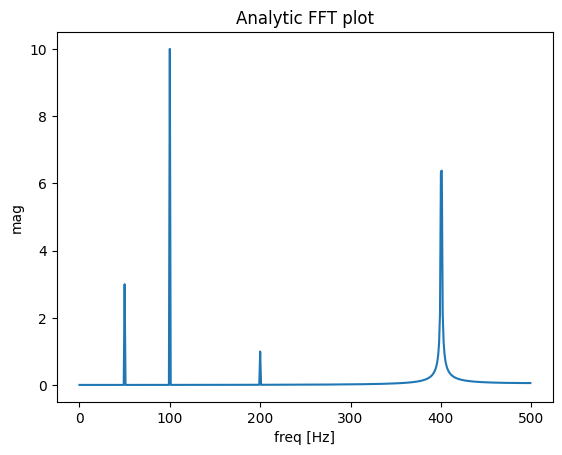

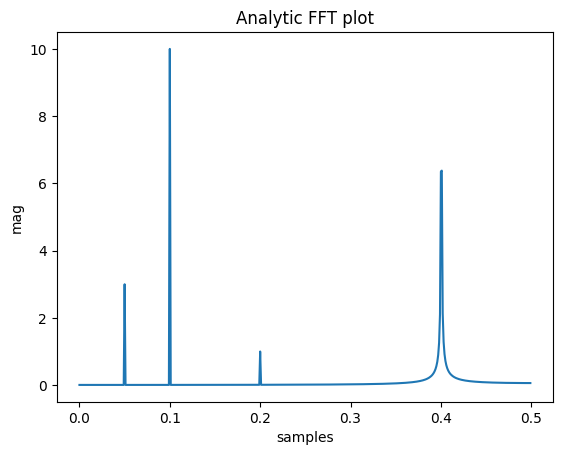

In [4]:
dt = 1 / 1000

# Build a signal within Nyquist - the result will be the positive FFT with actual magnitude
f0 = 200  # [Hz]
t = np.arange(0, 1 + dt, dt)
sig = (
    1 * np.sin(2 * np.pi * f0 * t)
    + 10 * np.sin(2 * np.pi * f0 / 2 * t)
    + 3 * np.sin(2 * np.pi * f0 / 4 * t)
    + 10 * np.sin(2 * np.pi * (f0 * 2 + 0.5) * t)  # <--- not sampled on grid so the peak will not be actual height
)
# Result in frequencies
fftPlot(sig, dt=dt)
# Result in samples (if the frequencies axis is unknown)
fftPlot(sig)

In [9]:
import scipy.io.wavfile as wavfile
import scipy
import scipy.fftpack
from scipy.fft import rfft, rfftfreq

N: 241316


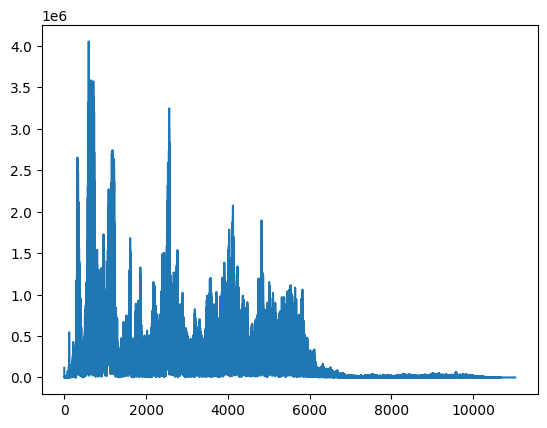

In [10]:
fs_rate, signal = wavfile.read("../data/sound/count_to_10_mono_22050.wav")
N = len(signal)
print(f'N: {N}')
yf = rfft(signal)
xf = rfftfreq(N, 1 / fs_rate)

plt.plot(xf, np.abs(yf))
plt.show()